# Model Comparison & Feature Engineering
**Notebook 04 — IDX Exchange Data Science Internship 2026**

This notebook covers two weeks of work:
- **Week 5:** Training and comparing Decision Tree and Random Forest models against the Linear Regression baseline
- **Week 6:** Feature engineering including derived property features and a geographic school district layer

**Input:** `train_cleaned.csv` and `test_cleaned.csv` from Notebook 02  
**Output:** `train_enriched.csv` and `test_enriched.csv` with engineered features

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from matplotlib.ticker import StrMethodFormatter
from sklearn.tree import DecisionTreeRegressor
import random
np.random.seed(42)

#util functions
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse, 
            "MAE": mae, "MAPE": mape, "MdAPE": mdape}

In [3]:
# loading in data

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
train_df = pd.read_csv(filepath + r"\train_cleaned.csv", low_memory=False)
test_df = pd.read_csv(filepath + r"\test_cleaned.csv", low_memory=False)

print("HighSchoolDistrict" in train_df)
drop_cols = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket", "HighSchoolDistrict"
]

x_train = train_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_test = test_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

if 'StateOrProvince_CA' in x_train.columns:
    before = len(x_train)
    ca_mask = x_train['StateOrProvince_CA'] == 1
    x_train = x_train[ca_mask]
    y_train = y_train[ca_mask]
    print(f"Removed {before - len(x_train)} non-CA rows from training data")
    print(f"X_train after CA filter: {x_train.shape}")

print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")

True
Removed 20 non-CA rows from training data
X_train after CA filter: (315663, 50)
X_train: (315663, 50)
X_test: (12634, 50)


## 1. Baseline Comparison — Linear Regression

The Linear Regression baseline from Notebook 03 is rerun here for direct 
comparison against the new models trained in this notebook.

In [7]:
# rerunning baseline linear regression for comparison
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
results_lr = evaluate_model(y_test, y_pred_lr, label="Linear Regression (Baseline)")
print(results_lr)


Linear Regression (Baseline)
R²:    0.4787
RMSE:  $653,554
MAE:   $436,579
MAPE:  43.80%
MdAPE: 30.37%
{'Model': 'Linear Regression (Baseline)', 'R2': 0.47874912423779004, 'RMSE': 653553.522122661, 'MAE': 436579.4976650309, 'MAPE': 43.795098654926804, 'MdAPE': 30.374212454212458}


## 2. Decision Tree

A decision tree learns to predict prices by asking a series of yes/no questions 
about a property, splitting the data into branches based on feature values.

**Key characteristic:** Decision trees tend to overfit if allowed to grow without 
limits. The `max_depth` parameter controls how deep the tree can grow, a larger 
depth captures more complex patterns but risks memorizing the training data rather 
than learning generalizable patterns.

The gap between Train R² and Test R² below indicates the degree of overfitting, 
a large gap means the model is memorizing rather than learning.

In [10]:
# decision tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
results_dt = evaluate_model(y_test, y_pred_dt, label="Decision Tree")

# check for overfitting - compare train vs test R²
print(f"\nDecision Tree Train R²: {r2_score(y_train, dt.predict(x_train)):.4f}")
print(f"Decision Tree Test R²:  {r2_score(y_test, y_pred_dt):.4f}")


Decision Tree
R²:    0.7805
RMSE:  $424,130
MAE:   $242,766
MAPE:  19.71%
MdAPE: 13.85%

Decision Tree Train R²: 0.8163
Decision Tree Test R²:  0.7805


## 3. Random Forest

A Random Forest builds many decision trees independently and averages their 
predictions. Each tree is trained on a random subset of rows and features, 
which forces diversity across the ensemble and significantly reduces overfitting 
compared to a single decision tree.

**Parameters:**
- `n_estimators=100` — number of trees in the forest
- `max_depth=15` — maximum depth of each individual tree
- `n_jobs=-1` — use all CPU cores to speed up training

The Train R² vs Test R² comparison below confirms whether the ensemble is 
generalizing well to unseen data.

In [12]:
# random forest
# n_estimators = number of trees, can be tuned as a hyperparameter
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
results_rf = evaluate_model(y_test, y_pred_rf, label="Random Forest")

# check for overfitting
print(f"\nRandom Forest Train R²: {r2_score(y_train, rf.predict(x_train)):.4f}")
print(f"Random Forest Test R²:  {r2_score(y_test, y_pred_rf):.4f}")


Random Forest
R²:    0.8815
RMSE:  $311,649
MAE:   $166,976
MAPE:  13.17%
MdAPE: 8.93%

Random Forest Train R²: 0.9464
Random Forest Test R²:  0.8815


## 4. Model Comparison — Baseline Results

The table and plots below compare all three models on the held-out test set. 
Points close to the red diagonal line in each scatter plot represent accurate 
predictions, the tighter the cluster around the line, the better the model.

**Strengths and Weaknesses:**
- **Linear Regression** — fast and interpretable but assumes linear relationships, limiting its ability to capture complex pricing patterns
- **Decision Tree** — captures non-linear relationships but prone to overfitting; performance controlled by `max_depth`
- **Random Forest** — most robust of the three; averaging across 100 trees reduces overfitting and improves generalization

In [18]:
# side by side comparison
results_table = pd.DataFrame([results_lr, results_dt, results_rf])
results_table = results_table.set_index("Model")
results_table = results_table.round(4)
print(results_table)

                                  R2         RMSE          MAE     MAPE  \
Model                                                                     
Linear Regression (Baseline)  0.4787  653553.5221  436579.4977  43.7951   
Decision Tree                 0.7805  424129.7987  242765.6924  19.7080   
Random Forest                 0.8815  311648.6947  166976.2376  13.1729   

                                MdAPE  
Model                                  
Linear Regression (Baseline)  30.3742  
Decision Tree                 13.8540  
Random Forest                  8.9312  


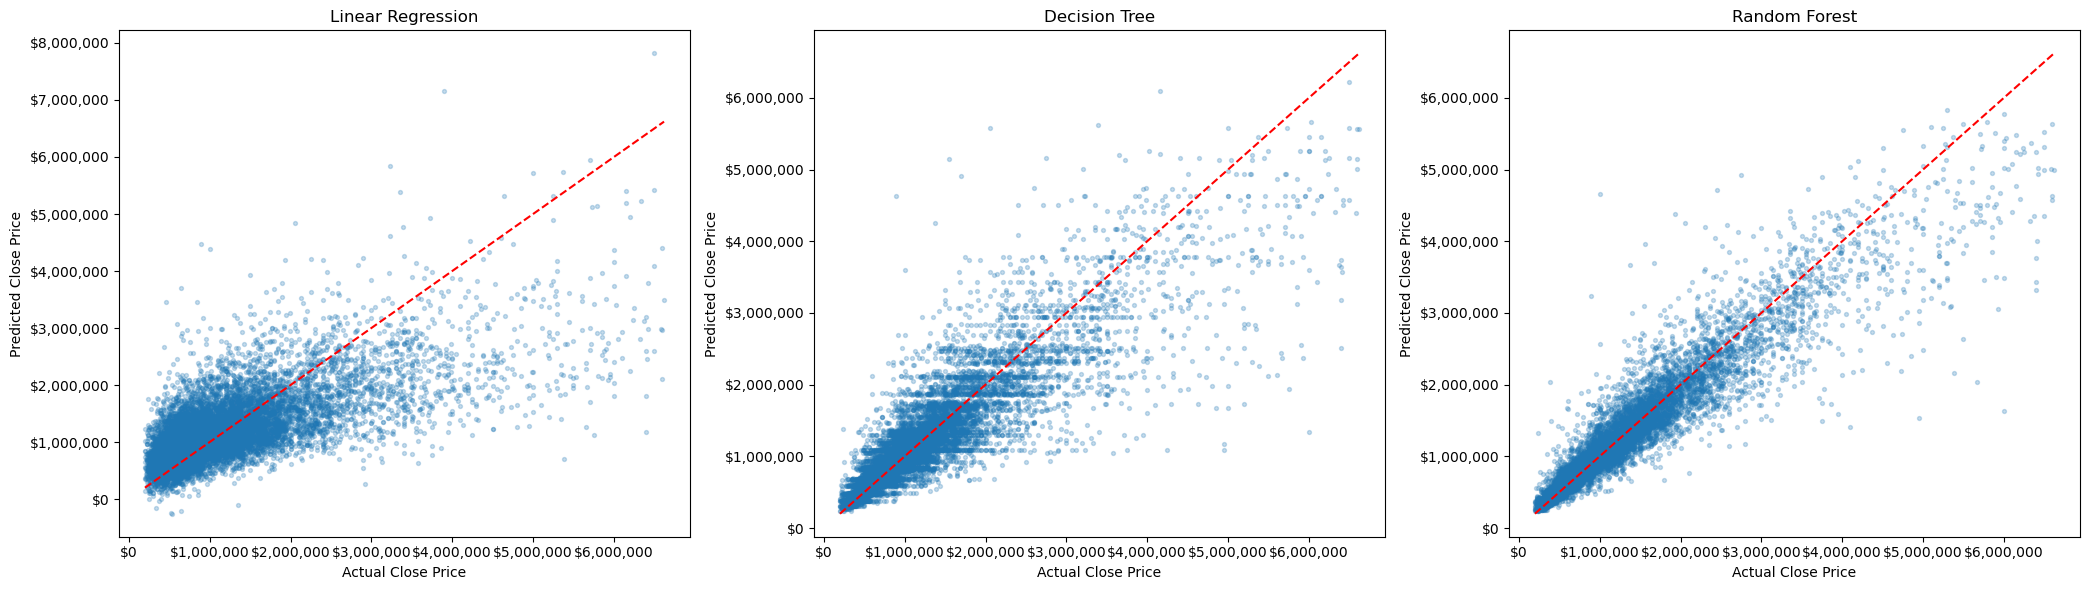

In [20]:
#residual graph
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

models = [
    ("Linear Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]

for ax, (name, preds) in zip(axes, models):
    ax.scatter(y_test, preds, alpha=0.25, s=8)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red", linestyle="--")
    ax.set_xlabel("Actual Close Price")
    ax.set_ylabel("Predicted Close Price")
    ax.set_title(name)
    ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.savefig(filepath + r"\model_comparison_plots.png", dpi=150, bbox_inches='tight')
plt.show()

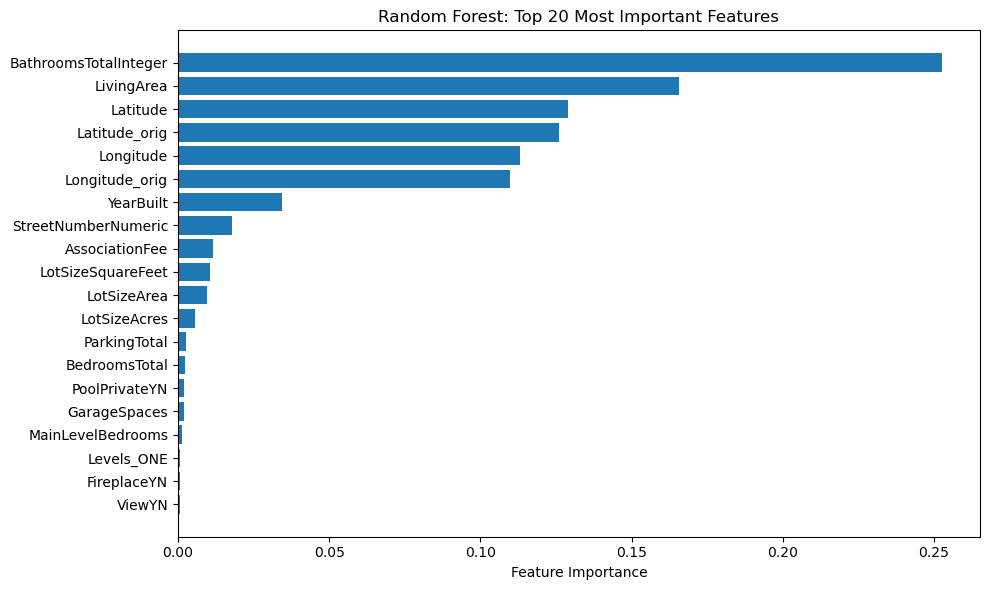

                  Feature  Importance
10  BathroomsTotalInteger    0.252553
4              LivingArea    0.165553
2                Latitude    0.129116
48          Latitude_orig    0.125856
3               Longitude    0.113220
49         Longitude_orig    0.109623
8               YearBuilt    0.034502
9     StreetNumberNumeric    0.017987
18         AssociationFee    0.011674
19      LotSizeSquareFeet    0.010639
14            LotSizeArea    0.009619
7            LotSizeAcres    0.005722
6            ParkingTotal    0.002634
11          BedroomsTotal    0.002166
1           PoolPrivateYN    0.001994
17           GarageSpaces    0.001942
15      MainLevelBedrooms    0.001248
33             Levels_ONE    0.000786
12            FireplaceYN    0.000756
0                  ViewYN    0.000521


In [22]:
# feature importance
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest: Top 20 Most Important Features")
plt.tight_layout()
plt.show()

print(importance_df)

## 5. Feature Engineering (Week 6)

This section expands the feature set to improve predictive power through two types 
of feature engineering: derived property features and a geographic school district layer.

### Derived Features
Three new features are created from existing property characteristics:

| Feature | Formula | Rationale |
|---|---|---|
| `BedBathRatio` | BedroomsTotal / BathroomsTotalInteger | Captures living space configuration |
| `PropertyAge` | 2026 - YearBuilt | Age of property at time of sale |
| `AreaPerBedroom` | LivingArea / BedroomsTotal | Spaciousness per bedroom |

Note: A small constant (1e-9) is added to denominators to prevent division by zero.

In [25]:
# week 6 feature engineering
# new features on the test/train data
for df in [train_df, test_df]:
    # bed/bath ratio
    df["BedBathRatio"] = df["BedroomsTotal"] / (df["BathroomsTotalInteger"] + 1e-9)

    # property age at time of sale
    df['PropertyAge'] = 2026 - df['YearBuilt']

    #living area per bedroom
    df['AreaPerBedroom'] = df['LivingArea'] / (df['BedroomsTotal'] + 1e-9)

print("New Features Added: BedBathRatio, PropertyAge, AreaPerBedroom")

New Features Added: BedBathRatio, PropertyAge, AreaPerBedroom


## 6. School District Geographic Layer

California Unified School District boundaries were downloaded from the California 
Open Data Portal (2025-26 boundaries) and spatially joined to each property using 
its latitude and longitude coordinates.

**Process:**
1. Load school district boundary polygons (GeoJSON)
2. Filter to Unified districts only (345 districts)
3. Convert each property's coordinates to a geographic point using `shapely`
4. Perform spatial join (`gpd.sjoin`) to assign each property to its district
5. Label encode `DistrictName` into `DistrictEncoded` using training data only

**Leakage prevention:** The LabelEncoder is fit on training data only. Properties 
in the test set whose district was not seen in training are mapped to "Unknown", 
which was included in the encoder fit to handle future months of data.

**Coordinate system:** Both property points and district polygons are converted 
to EPSG:4326 (standard lat/lon degrees) before joining.

In [28]:
# adding the school district spacial join, importing GeoPandas school district data
import geopandas as gpd
from shapely.geometry import Point

districts = gpd.read_file(r"C:\Users\julia\Downloads\IDX_summer_internship\ca_school_districts.geojson")
print(f"Districts loaded: {len(districts)}")
print(f"Columns: {districts.columns.tolist()}")

Districts loaded: 936
Columns: ['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']


In [30]:
# filttering the school district dataset to only include "unified" (unified school districts only)

unified = districts[districts['DistrictType'] == 'Unified'].copy()
print(f"unified districtics: {len(unified)}")

unified districtics: 345


In [31]:
# converting each property's latitude and longitude into a geographic point

def add_school_district(df, districts_gdf):
    # convert lat/lon to geographic points -> creates a list of geographic Point objects, one per property
    geometry = [Point(lon, lat) for lon, lat in zip(df["Longitude_orig"], df["Latitude_orig"])]    # create geodataframe -> wraps pd df into a GeoPandas GeoDataFrame by attaching geometry column just created
    props_gdf = gpd.GeoDataFrame(df.copy(), geometry=geometry, crs="EPSG:4326") #EPSG is notation for standatd lat/lon degrees
    districts_gdf = districts_gdf.to_crs("EPSG:4326")

    # match CRS -> checks if school districut are in the same coordinate system, if not it converts it to match 
    if districts_gdf.crs != props_gdf.crs:
        districts_gdf = districts_gdf.to_crs("EPSG:4326")
    
    # spatial join -> for each property point finds which polygon it falls inside
    joined = gpd.sjoin(props_gdf,
                       districts_gdf[["DistrictName", "geometry"]],
                       how="left",
                       predicate="within")
    
    # drop geometry columns
    joined = joined.drop(columns=["geometry", "index_right"], errors="ignore")
    
    return pd.DataFrame(joined)
    
# run spatial join on train and test
print("Joining train data...")
train_df = add_school_district(train_df, unified)
print(f"Train done! Districts assigned: {train_df['DistrictName'].notna().sum():,}")

print("Joining test data...")
test_df = add_school_district(test_df, unified)
print(f"Test done! Districts assigned: {test_df['DistrictName'].notna().sum():,}")

Joining train data...
Train done! Districts assigned: 236,560
Joining test data...
Test done! Districts assigned: 9,509


In [34]:
# label encoding district
from sklearn.preprocessing import LabelEncoder

# fill missing districts with Unknown
train_df["DistrictName"] = train_df["DistrictName"].fillna("Unknown")
test_df["DistrictName"] = test_df["DistrictName"].fillna("Unknown")

# fit on training data - Unknown is in training so encoder learns it
le = LabelEncoder()
le.fit(train_df["DistrictName"])

train_df["DistrictEncoded"] = le.transform(train_df["DistrictName"])

# any test districts not seen in training get mapped to Unknown
test_df["DistrictName"] = test_df["DistrictName"].apply(
    lambda x: x if x in le.classes_ else "Unknown"
)
test_df["DistrictEncoded"] = le.transform(test_df["DistrictName"])

print(f"Unique districts encoded: {len(le.classes_)}")
print(f"Sample mapping:")
for name, code in zip(le.classes_[:5], range(5)):
    print(f"  {name} → {code}")

# save enriched datasets
train_df.to_csv(filepath + r"\train_enriched.csv", index=False)
test_df.to_csv(filepath + r"\test_enriched.csv", index=False)
print(f"train_enriched.csv saved — {len(train_df):,} rows")
print(f"test_enriched.csv saved — {len(test_df):,} rows")

Unique districts encoded: 324
Sample mapping:
  ABC Unified → 0
  Acton-Agua Dulce Unified → 1
  Alameda Unified → 2
  Albany City Unified → 3
  Alhambra Unified → 4
train_enriched.csv saved — 315,683 rows
test_enriched.csv saved — 12,634 rows


In [36]:
# rebuilding features with all new engineered columns
drop_cols_eng = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket",
    "HighSchoolDistrict", "DistrictName",
    "Latitude_orig", "Longitude_orig",
    "DistrictMedianPrice"
]

x_train_eng = train_df.drop(columns=["ClosePrice"] + drop_cols_eng, errors="ignore")
x_test_eng = test_df.drop(columns=["ClosePrice"] + drop_cols_eng, errors="ignore")
y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

# drop any remaining object columns
obj_cols = x_train_eng.select_dtypes(include="object").columns.tolist()
if obj_cols:
    print(f"Dropping object columns: {obj_cols}")
    x_train_eng = x_train_eng.drop(columns=obj_cols)
    x_test_eng = x_test_eng.drop(columns=obj_cols)

print(f"X_train_eng: {x_train_eng.shape}")
print(f"X_test_eng: {x_test_eng.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train_eng: (315683, 52)
X_test_eng: (12634, 52)
y_train: (315683,)
y_test: (12634,)


## 7. Retrain with Engineered Features

The Random Forest is retrained on the full enriched feature set (52 features) 
to measure the impact of feature engineering. The comparison table below shows 
performance before and after engineering.

The feature importance chart reveals which features the model relies on most, 
confirming whether the new engineered features and school district layer added 
meaningful predictive signal.

In [39]:
# retraining fandom forest with new features
rf_eng = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_eng.fit(x_train_eng, y_train)
y_pred_rf_eng = rf_eng.predict(x_test_eng)
results_rf_eng = evaluate_model(y_test, y_pred_rf_eng, label="Random Forest (engineered features)")


Random Forest (engineered features)
R²:    0.8920
RMSE:  $297,504
MAE:   $154,714
MAPE:  11.98%
MdAPE: 7.95%


In [42]:
#building comparison table between all methods so far
comparison = pd.DataFrame([results_lr, results_dt, results_rf, results_rf_eng])
comparison = comparison.set_index("Model")

# format columns nicely
comparison["R2"] = comparison["R2"].map("{:.4f}".format)
comparison["RMSE"] = comparison["RMSE"].map("${:,.0f}".format)
comparison["MAE"] = comparison["MAE"].map("${:,.0f}".format)
comparison["MAPE"] = comparison["MAPE"].map("{:.2f}%".format)
comparison["MdAPE"] = comparison["MdAPE"].map("{:.2f}%".format)

# rename columns
comparison.columns = ["R²", "RMSE", "MAE", "MAPE", "MdAPE"]

comparison.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12pt',
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'center'),
              ('font-size', '12pt'),
              ('font-weight', 'bold')]
}])

,R²,RMSE,MAE,MAPE,MdAPE
Model,,,,,
Linear Regression (Baseline),0.4787,"$653,554","$436,579",43.80%,30.37%
Decision Tree,0.7805,"$424,130","$242,766",19.71%,13.85%
Random Forest,0.8815,"$311,649","$166,976",13.17%,8.93%
Random Forest (engineered features),0.8920,"$297,504","$154,714",11.98%,7.95%


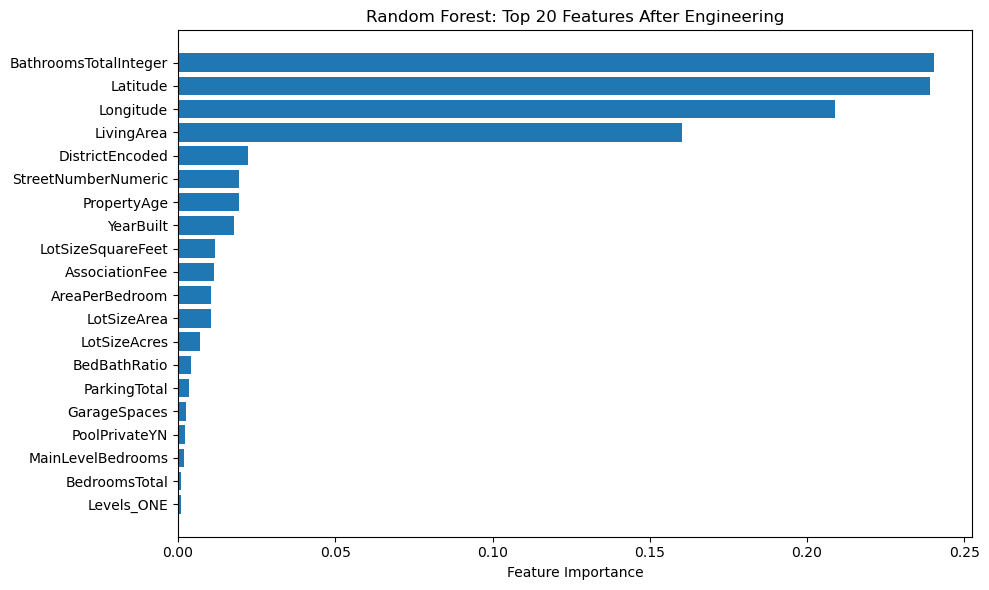

                  Feature  Importance
10  BathroomsTotalInteger    0.240499
2                Latitude    0.239001
3               Longitude    0.208754
4              LivingArea    0.160388
51        DistrictEncoded    0.022421
9     StreetNumberNumeric    0.019494
49            PropertyAge    0.019343
8               YearBuilt    0.017940
19      LotSizeSquareFeet    0.011703
18         AssociationFee    0.011390
50         AreaPerBedroom    0.010646
14            LotSizeArea    0.010630
7            LotSizeAcres    0.007033
48           BedBathRatio    0.004212
6            ParkingTotal    0.003644
17           GarageSpaces    0.002476
1           PoolPrivateYN    0.002148
15      MainLevelBedrooms    0.001782
11          BedroomsTotal    0.001096
33             Levels_ONE    0.000953


In [44]:
# feature importance with new features
importance_df = pd.DataFrame({
    "Feature": x_train_eng.columns,
    "Importance": rf_eng.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest: Top 20 Features After Engineering")
plt.tight_layout()
plt.show()

print(importance_df)

---
**Feature Engineering Impact:**

| Model | R² | MdAPE |
|---|---|---|
| Random Forest (baseline features) | 0.8806 | 8.95% |
| Random Forest (engineered features) | 0.8920 | 7.95% |

Adding BedBathRatio, PropertyAge, AreaPerBedroom, and DistrictEncoded improved 
MdAPE by 1 percentage point. DistrictEncoded ranked as the 5th most important 
feature, confirming the school district layer added real predictive value.

---
*Next: 05_advanced_models.ipynb — LightGBM and XGBoost with hyperparameter tuning*